In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [78]:
df_main = pd.read_csv("Titanic-Dataset.csv")
df = df_main.copy()


In [79]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [80]:
display(df.shape)

(891, 12)

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [82]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [83]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Data Cleaning


1.There are many null value in cabin col. which does not good for us also cabin does not give any usefull insight. So we drop this col.  

2.In age col we have null value but not that much like cabin col. so we can fill that null we avg.  

3.In Embarked col we have only 2 value which is null there is can use ffill or bfill both are good so we can use anyone.

In [84]:
df.drop(columns="Cabin",inplace=True)

In [85]:
age = df['Age'].median()
df['Age'] = df['Age'].fillna(age)

In [86]:
df['Embarked'].ffill(inplace=True)

In [87]:
df['Family_Size'] = df['SibSp']+df['Parch']+1


In [88]:
df['Title'] = df['Name'].str.split(",",expand=True)[1].str.split(".",expand=True)[0]
df['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [89]:
df['Title'] = df['Title'].replace(['Master','Dr','Rev','Col','Major','Don','Lady','Jonkheer','the Countess'],'Rare')
df['Title'] = df['Title'].replace(['Mlle','Ms'],'Miss')
df['Title'] = df['Title'].replace('Mme','Mrs')

In [90]:
df.drop(columns=['Name','SibSp','Parch','Ticket'],inplace=True)

In [91]:
df.sample(5)

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,Family_Size,Title
710,711,1,1,female,24.0,49.5042,C,1,Mlle
465,466,0,3,male,38.0,7.0500,S,1,Mr
113,114,0,3,female,20.0,9.8250,S,2,Miss
220,221,1,3,male,16.0,8.0500,S,1,Mr
198,199,1,3,female,28.0,7.7500,Q,1,Miss


In [92]:
def family_size(number):
    if number == 1:
        return "Alone"
    elif number>1 and number <5:
        return "Small"
    else:
        return "Large"

In [93]:
df['Family_Size'] = df['Family_Size'].apply(family_size)

# Visualization

In [94]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,Family_Size,Title
0,1,0,3,male,22.0,7.2500,S,Small,Mr
1,2,1,1,female,38.0,71.2833,C,Small,Mrs
2,3,1,3,female,26.0,7.9250,S,Alone,Miss
3,4,1,1,female,35.0,53.1000,S,Small,Mrs
4,5,0,3,male,35.0,8.0500,S,Alone,Mr


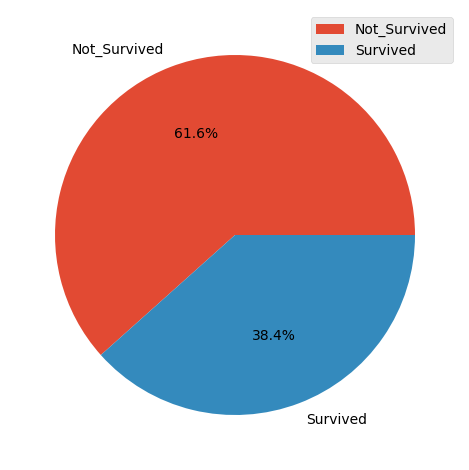

In [108]:
survived = df['Survived'].value_counts().reset_index()
mylables = ['Not_Survived','Survived']
plt.style.use('ggplot')
plt.pie(survived["count"],labels= mylables,autopct='%1.1f%%')
plt.legend()
plt.tight_layout()
plt.show()

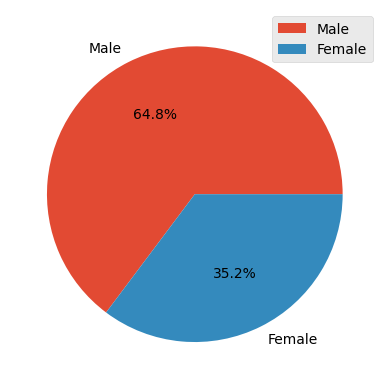

In [96]:
sex_ratio = df['Sex'].value_counts().reset_index()
sex_label = ['Male','Female']
plt.pie(sex_ratio['count'],labels=sex_label,autopct='%1.1f%%')
plt.legend()
plt.show()

Text(0.5, 1.0, '')

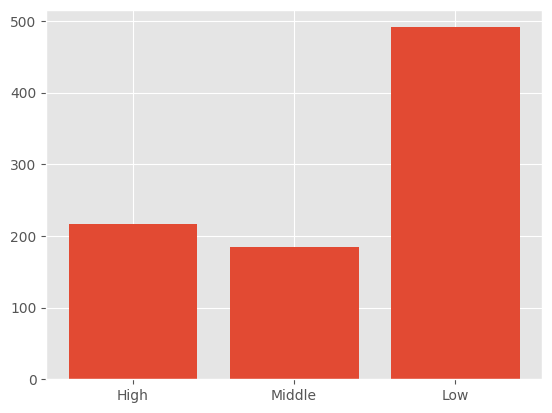

In [103]:
class_money = df['Pclass'].value_counts().reset_index().sort_values('Pclass')
class_money['class_name'] = ['High','Middle','Low']
plt.bar(class_money['class_name'],class_money['count'])
plt.title("")

In [98]:
family_sizes = df['Family_Size'].value_counts().reset_index()
family_sizes

,Family_Size,count
0,Alone,537
1,Small,292
2,Large,62


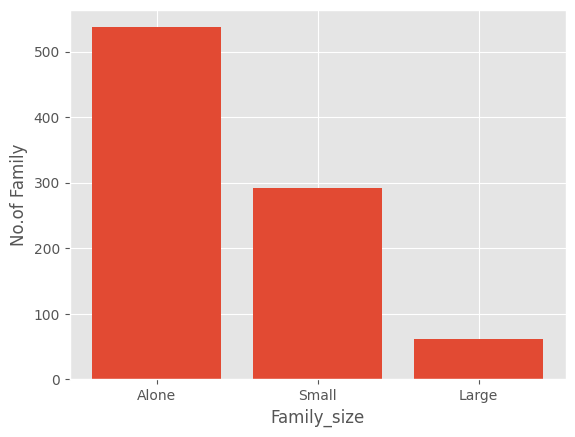

In [ ]:
plt.bar(family_sizes['Family_Size'],family_sizes['count'])
plt.xlabel("Family_size")
plt.ylabel("No.of Family")
plt.show()

In [120]:
df['Fare'].value_counts().reset_index().sort_values('count').head(10)

,Fare,count
192,6.8583,1
193,35.0000,1
194,6.2375,1
195,55.4417,1
196,4.0125,1
197,211.5000,1
198,7.7292,1
199,12.0000,1
200,28.5000,1
201,75.2500,1


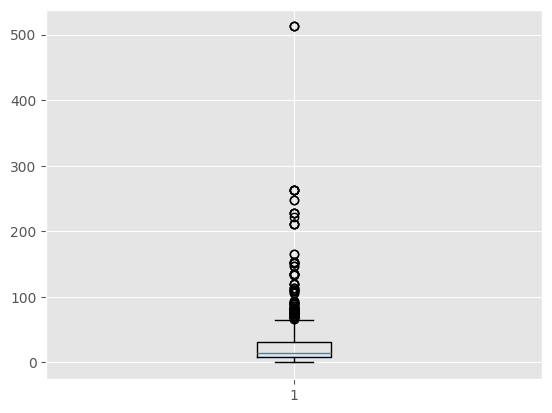

In [138]:
plt.boxplot(df['Fare'])
plt.show() # this is good for fare or price of ticket varrying

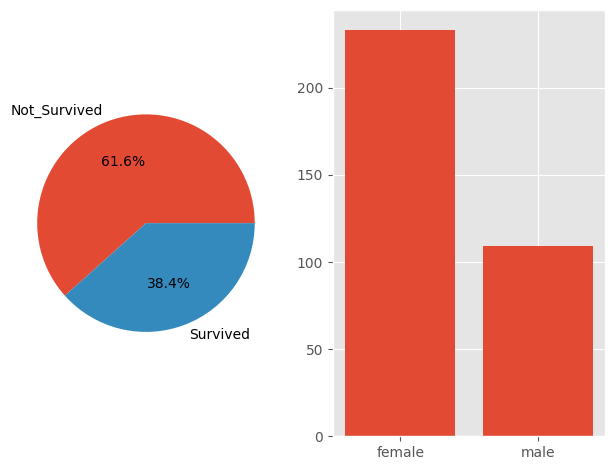

In [133]:
# # Which sex survive most 


survived = df['Survived'].value_counts().reset_index()
mylables = ['Not_Survived','Survived']
fig,(ax1,ax2) = plt.subplots(1,2)
ax1.pie(survived["count"],labels= mylables,autopct='%1.1f%%')

sex_ratio_survive = df[df['Survived']==1]['Sex'].value_counts().reset_index()
ax2.bar(sex_ratio_survive['Sex'],sex_ratio_survive['count'])
plt.tight_layout()
plt.show()